# Narrabeen: Cross-shore time series of shoreline changes as intersection of RTS-DTM with horizontal plane at sea level

## Imports

In [1]:
%load_ext autoreload
%autoreload 2
    
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np
from scipy.interpolate import griddata
from shapely import distance

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import gridspec
from matplotlib.colors import LinearSegmentedColormap

from coastal_data import CD_jarkus_tools, CD_helper_functions, CD_statistics, CD_geometry

/home/bene/PhD-git/envs/universe/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# matplotlib fontsizes
SMALL_SIZE = 15
MEDIUM_SIZE = 18
BIGGER_SIZE = 25

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)   # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

## Paths

In [3]:
path_to_data_folder = '/media/bene/Seagate/PhD-data/98_paper2_kf_dtm/'
# path_to_data_folder = '/home/jovyan/data/98_paper2_kf_dtm/'

path_rtsdtm = path_to_data_folder+'32_33_Narrabeen_DEM/output/'
path_input_general = path_to_data_folder+'0_input_general/'
path_altimetry_input = path_to_data_folder+'31_Narra_altimetry/input/'
path_altimetry_output = path_to_data_folder+'31_Narra_altimetry/output/'

In [4]:
epsg_local = 32356

## Get RTS-DTM on validation transects

In [5]:
fn_rtsdtm = 'x_state_s_readd.pkl'
x_state_s = pickle.load(open(path_rtsdtm + fn_rtsdtm, 'rb'))

In [6]:
vali_gdf = gpd.read_file(path_rtsdtm + 'narra_vali_gdf.geojson')

In [7]:
rts_gdf = gpd.GeoDataFrame(index=vali_gdf.index, columns=vali_gdf.columns)
rts_gdf.geometry = vali_gdf.geometry

year_list = [int(col.split('_')[-1]) for col in x_state_s.columns if col.startswith('x_s_')]
# year = year_list[0]
for year in year_list:
    mx = x_state_s.geometry.x
    my = x_state_s.geometry.y
    values = x_state_s[f'x_s_{year}']
    interp = griddata(list(zip(mx,my)), values, (vali_gdf.geometry.x,vali_gdf.geometry.y), 'linear')
    rts_gdf[str(year)] = interp

In [8]:
vali_gdf = vali_gdf.to_crs(epsg_local)
rts_gdf = rts_gdf.to_crs(epsg_local)

### Remove height difference rts-vali
Bring validation data to SLA -> no need to reduce altimetry to TG then  
would be better to consider only differences in the shoreline area

In [9]:
diff = rts_gdf.drop(columns=['geometry']) - vali_gdf.drop(columns=['geometry'])

print(f'Mean of all differences (RTS - validation): {round(diff.mean().mean(), 2)}, median: {round(diff.median().median(), 2)}')
bias = diff.median().median()
vali_gdf = vali_gdf.copy()
vali_gdf.loc[:, vali_gdf.columns != 'geometry'] += bias

Mean of all differences (RTS - validation): -1.46, median: -0.72


### Separate into profiles

In [10]:
profile_polys = pickle.load(open(path_rtsdtm + 'profile_polys.pkl', 'rb'))

profiles_vali = {}
profiles_rts = {}

for profile in profile_polys.keys():
    profile_poly = CD_geometry.transform_polygon(profile_polys[profile], 4326, epsg_local)
    profiles_rts[profile] = rts_gdf[rts_gdf.intersects(profile_poly)]
    profiles_vali[profile] = vali_gdf[vali_gdf.intersects(profile_poly)]

### ! Get cross-shore distance
Distances computed with shapely are not the same as the 'chainage' values in the original data set  
Probably too many conversion between crs

In [11]:
# Add cross-shore distance
for profile in profile_polys.keys():
    dists = []
    orig = profiles_vali[profile].iloc[0].geometry
    for i, point in enumerate(profiles_vali[profile].geometry):
        dists.append(distance(orig, point))

    profiles_rts[profile]['cross_shore'] = dists
    profiles_vali[profile]['cross_shore'] = dists

/home/bene/PhD-git/envs/universe/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/bene/PhD-git/envs/universe/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/bene/PhD-git/envs/universe/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

### Plot profiles

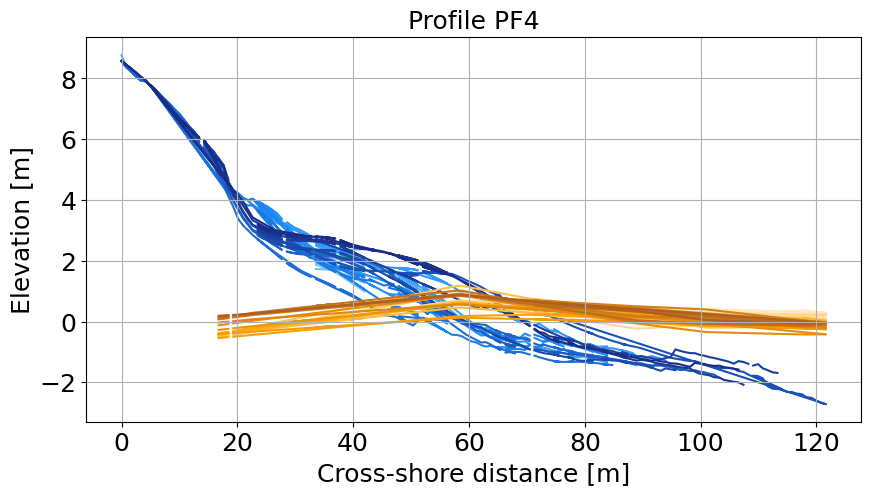

In [12]:
fig, ax = plt.subplots(figsize=(10,5))

profile_to_plot = 'PF4'
profile_rts = profiles_rts[profile_to_plot].drop(columns=['geometry', 'cross_shore'])
profile_vali = profiles_vali[profile_to_plot].drop(columns=['geometry', 'cross_shore'])

blues = ["powderblue", "dodgerblue", "midnightblue"]
cmap_blues = LinearSegmentedColormap.from_list("mycmap", blues).resampled(profiles_vali['PF1'].shape[1])
oranges = ["papayawhip", "orange", "sienna"]
cmap_oranges = LinearSegmentedColormap.from_list("mycmap", oranges).resampled(profiles_vali['PF1'].shape[1])

for i, year in enumerate(profile_rts.columns):
    ax.plot(profiles_rts[profile_to_plot].cross_shore, profile_rts[year], c=cmap_oranges(i), zorder=1)
    ax.plot(profiles_rts[profile_to_plot].cross_shore, profile_vali[year], c=cmap_blues(i), zorder=0)
    
ax.grid()
ax.set_title(f'Profile {profile_to_plot}')

ax.set_xlabel('Cross-shore distance [m]')
ax.set_ylabel('Elevation [m]')
    
legend_elements = [
        Line2D([0], [0], color=cmap_blues(0), label='Validation 1993'),
        Line2D([0], [0], color=cmap_blues(profiles_rts['PF4'].shape[1]), label='Validation 2020'),
        Line2D([0], [0], color=cmap_oranges(0), label='RTS-DTM 1993'),
        Line2D([0], [0], color=cmap_oranges(profiles_rts['PF4'].shape[1]), label='RTS-DTM 2020'),
    ]
# ax.legend(handles=legend_elements, bbox_to_anchor=(1.5,1))

plt.savefig(f'{path_rtsdtm}Narra_profile_examplePlot.png', dpi=300, bbox_inches='tight')

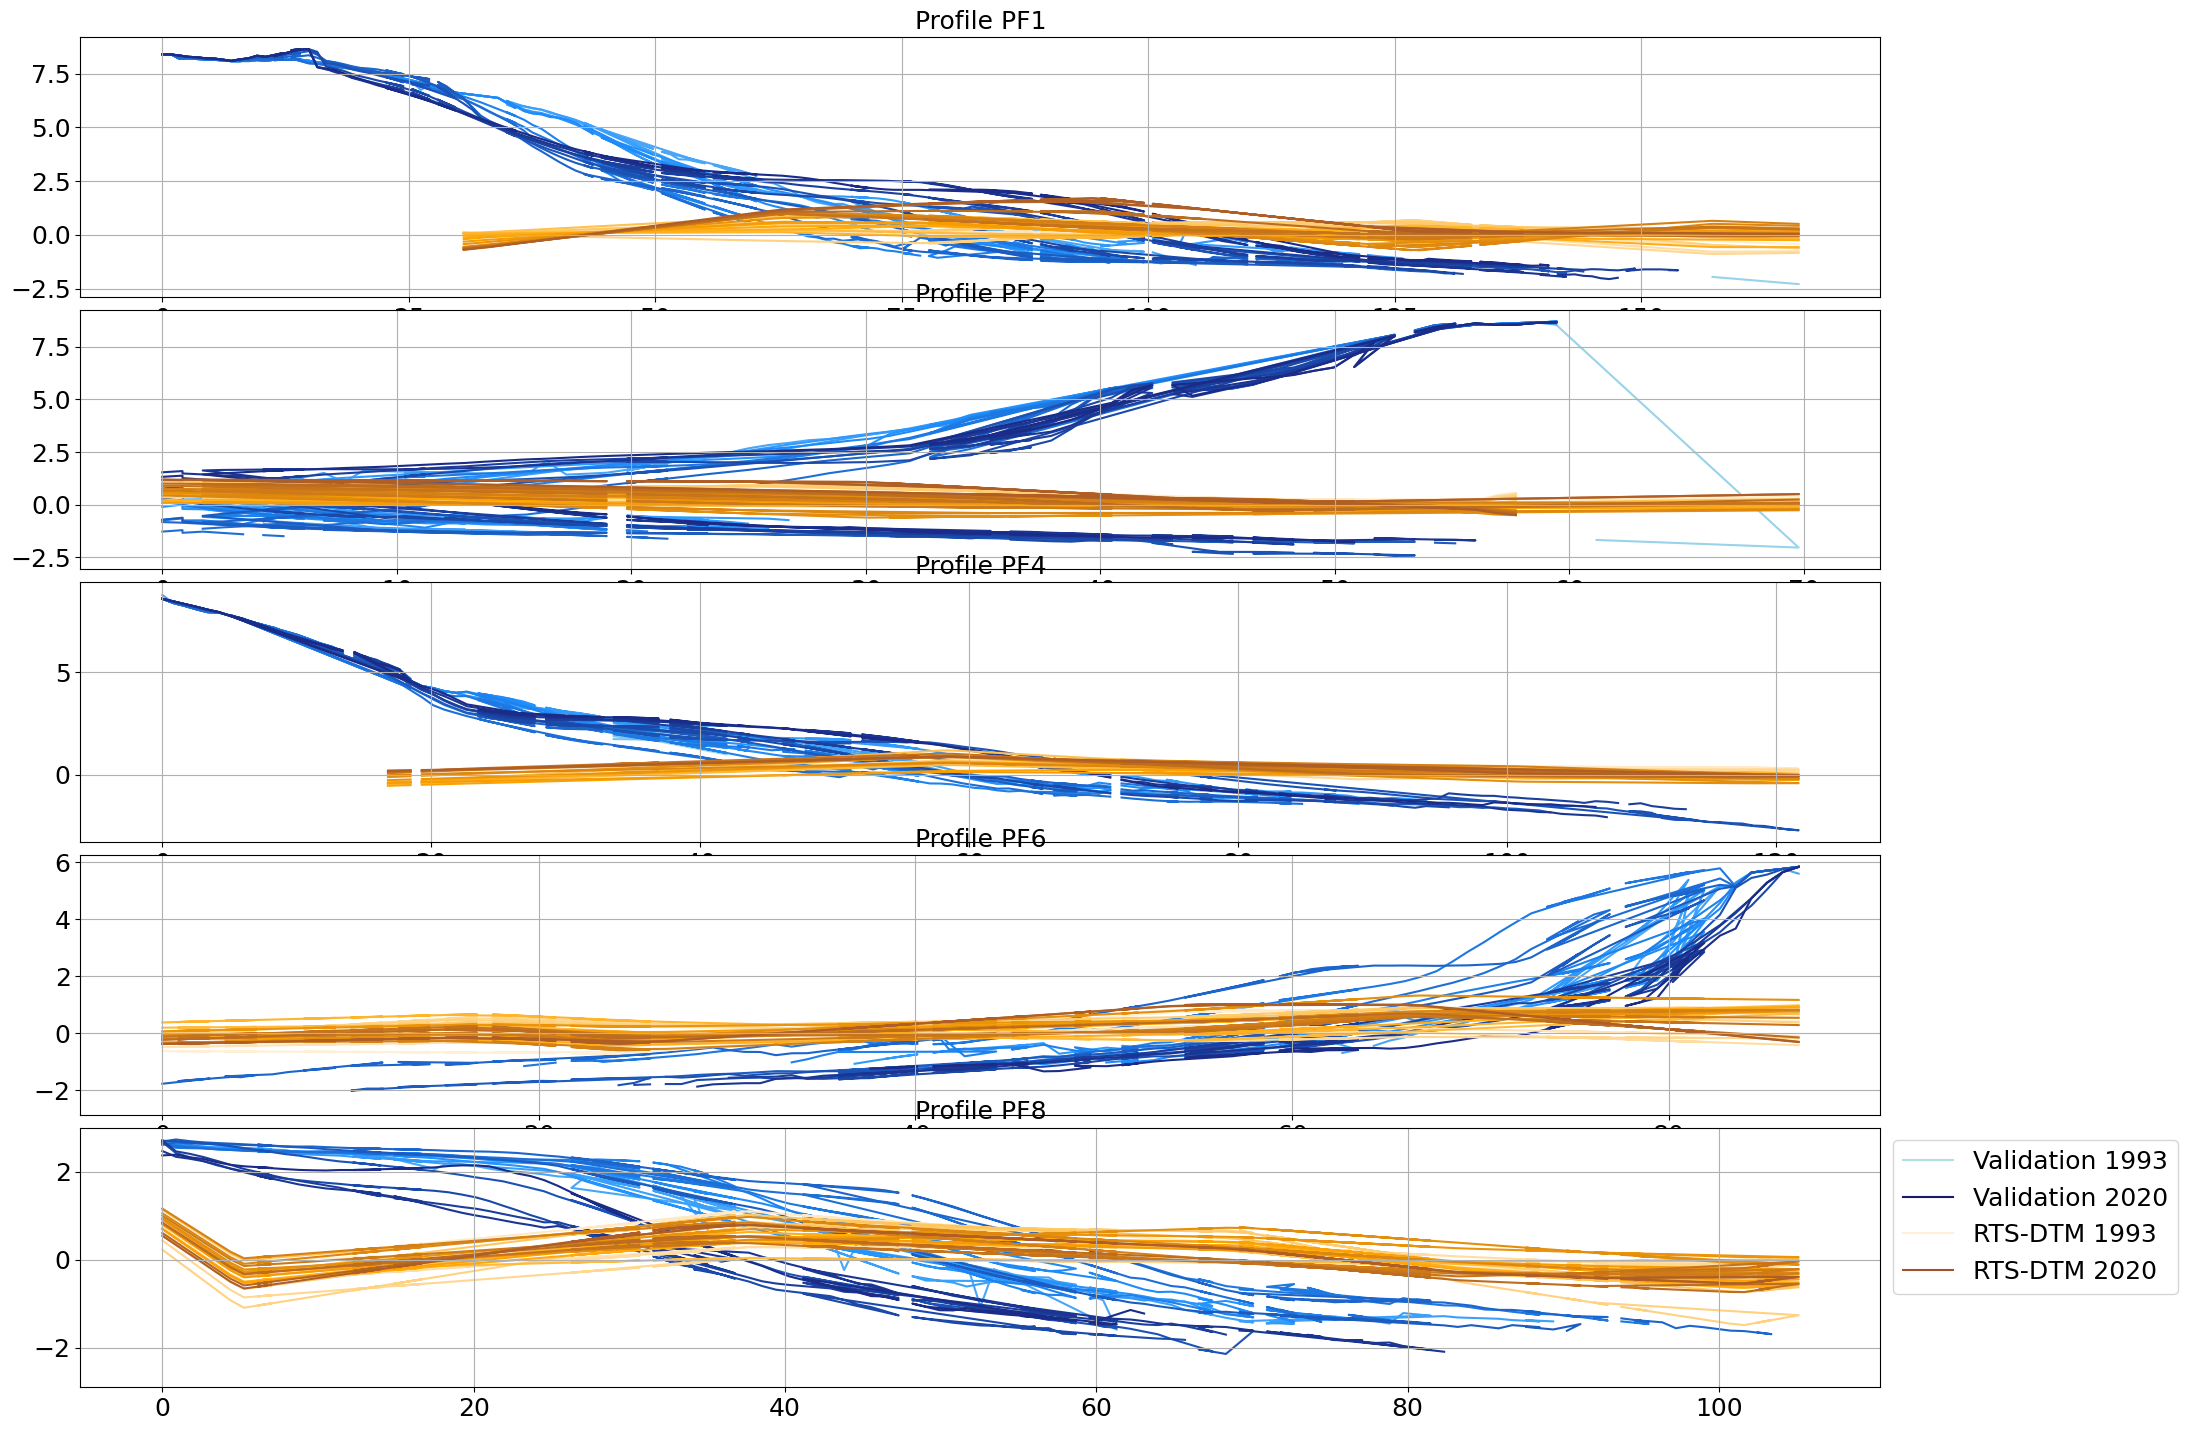

In [13]:
fig = plt.figure(figsize=[20,15])
fig.tight_layout()
gs = gridspec.GridSpec(len(profiles_rts),1)
gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95, hspace=0.05)

for i, profile in enumerate(profiles_rts.keys()):
    profile_rts = profiles_rts[profile].drop(columns=['geometry', 'cross_shore'])
    profile_vali = profiles_vali[profile].drop(columns=['geometry', 'cross_shore'])
    ax = fig.add_subplot(gs[int(i),0])

    for j, year in enumerate(profile_rts.columns):
        ax.plot(profiles_rts[profile].cross_shore, profile_rts[year], c=cmap_oranges(j), zorder=1)
        ax.plot(profiles_vali[profile].cross_shore, profile_vali[year], c=cmap_blues(j), zorder=0)
    
    ax.grid()
    ax.set_title(f'Profile {profile}')
legend_elements = [
        Line2D([0], [0], color=cmap_blues(0), label='Validation 1993'),
        Line2D([0], [0], color=cmap_blues(profiles_vali['PF1'].shape[1]), label='Validation 2020'),
        Line2D([0], [0], color=cmap_oranges(0), label='RTS-DTM 1993'),
        Line2D([0], [0], color=cmap_oranges(profiles_rts['PF1'].shape[1]), label='RTS-DTM 2020'),
    ]
ax.legend(handles=legend_elements, bbox_to_anchor=(1,1))

## Get sea level

In [14]:
# altimetry
fn = f'tp_plus_ales_epsg{epsg_local}.csv'
alt = pd.read_csv(path_altimetry_output+fn, index_col='time', parse_dates=['time'])
alt_yearly = alt['sla'].groupby(pd.Grouper(freq='YE')).mean()

In [15]:
fn = 'psmsl_monthly_RLR_NARRA.txt'
tg_psmsl_orig = pd.read_csv(path_altimetry_input+fn, sep=';', header=None, names=['date', 'SSH_RLR[mm]'])

tg_psmsl = pd.DataFrame()
tg_psmsl['date'] = CD_helper_functions.decimal_numbers_to_datetime(tg_psmsl_orig['date'])
tg_psmsl = tg_psmsl.set_index('date')

tg_psmsl['SSH_RLR[m]'] = tg_psmsl_orig['SSH_RLR[mm]'].values / 1000 - 6.995

# reduce to altimetry time period
tg_psmsl = tg_psmsl.iloc[np.nonzero(tg_psmsl.index.year >= 1992)[0]]

# remove weird -107 m values
idx, = np.where(tg_psmsl['SSH_RLR[m]'] > -100)
tg_psmsl= tg_psmsl.iloc[idx]

# yearly averages
tg_psmsl_yearly = tg_psmsl.groupby(pd.Grouper(freq='YE')).mean()

## Get intersections

In [16]:
def get_intersection(profiles, alt_yearly_red, static_profile=False, static_seaLevel=False):
    years = rts_gdf.drop(columns='geometry').columns.values.astype('int')
    cd_df = pd.DataFrame(index=profiles.keys(),
                         columns=years)

    if static_seaLevel == True:
        ssh = 0
        
    for key in profiles.keys():
        transect = profiles[key]

        for year in years:
            if static_profile == True:
                profile = transect['1993']
            else:
                profile = transect[str(year)]
            
            idx_time, = np.where(alt_yearly_red.index.year == year)
            ssh = alt_yearly_red.iloc[idx_time].values   

            intersections = CD_jarkus_tools.find_intersections(profile, ssh, transect.cross_shore.values)
            DuneTop_prim_x = CD_jarkus_tools.find_primary_dunetop(profile, transect.cross_shore.values)
            cd = CD_jarkus_tools.identify_coastline(intersections, DuneTop_prim_x)
            
            cd_df.loc[key, year] = cd
    return cd_df

In [17]:
# RTS-DTM
# Time-variable profile, time-variable sea level
cd_rts_variable = get_intersection(profiles_rts, alt_yearly, static_profile=False, static_seaLevel=False)
# Time-variable profile, static sea level
cd_rts_static_sl = get_intersection(profiles_rts, alt_yearly, static_profile=False, static_seaLevel=True)
# Static profile, time-variable sea level
cd_rts_static_profile = get_intersection(profiles_rts, alt_yearly, static_profile=True, static_seaLevel=False)

In [18]:
# Validation
# Time-variable profile, time-variable sea level
cd_vali_variable = get_intersection(profiles_vali, alt_yearly, static_profile=False, static_seaLevel=False)
# Time-variable profile, static sea level
cd_vali_static_sl = get_intersection(profiles_vali, alt_yearly, static_profile=False, static_seaLevel=True)
# Static profile, time-variable sea level
cd_vali_static_profile = get_intersection(profiles_vali, alt_yearly, static_profile=True, static_seaLevel=False)

## Trends

In [19]:
def get_shoreline_trends(cd):
    trend_df = pd.DataFrame(index=cd.index, columns=['trend', 'Cxx', 'v'])
    x = cd.columns.values.astype(int)
    
    n_nonNanValues = 5 # minimum number of non-NaN values per time series
    
    # transect = cd.index[0]
    for transect in cd.index:
        ts = cd.loc[transect].values.astype('float')
        
        if np.all(np.isnan(ts)):
            continue
        nr_non_nan = len(ts) - np.isnan(ts).sum() # number of non nan values
        if nr_non_nan < n_nonNanValues:
            continue
        else:
            trend_df.loc[transect, 'trend'], trend_df.loc[transect, 'Cxx'], trend_df.loc[transect, 'v'] = CD_statistics.compute_trend_with_error(x, ts)
    return trend_df

In [20]:
trend_rts_variable = get_shoreline_trends(cd_rts_variable)
trend_rts_static_sl = get_shoreline_trends(cd_rts_static_sl)
trend_rts_static_profile = get_shoreline_trends(cd_rts_static_profile)

In [21]:
trend_vali_variable = get_shoreline_trends(cd_vali_variable)
trend_vali_static_sl = get_shoreline_trends(cd_vali_static_sl)
trend_vali_static_profile = get_shoreline_trends(cd_vali_static_profile)

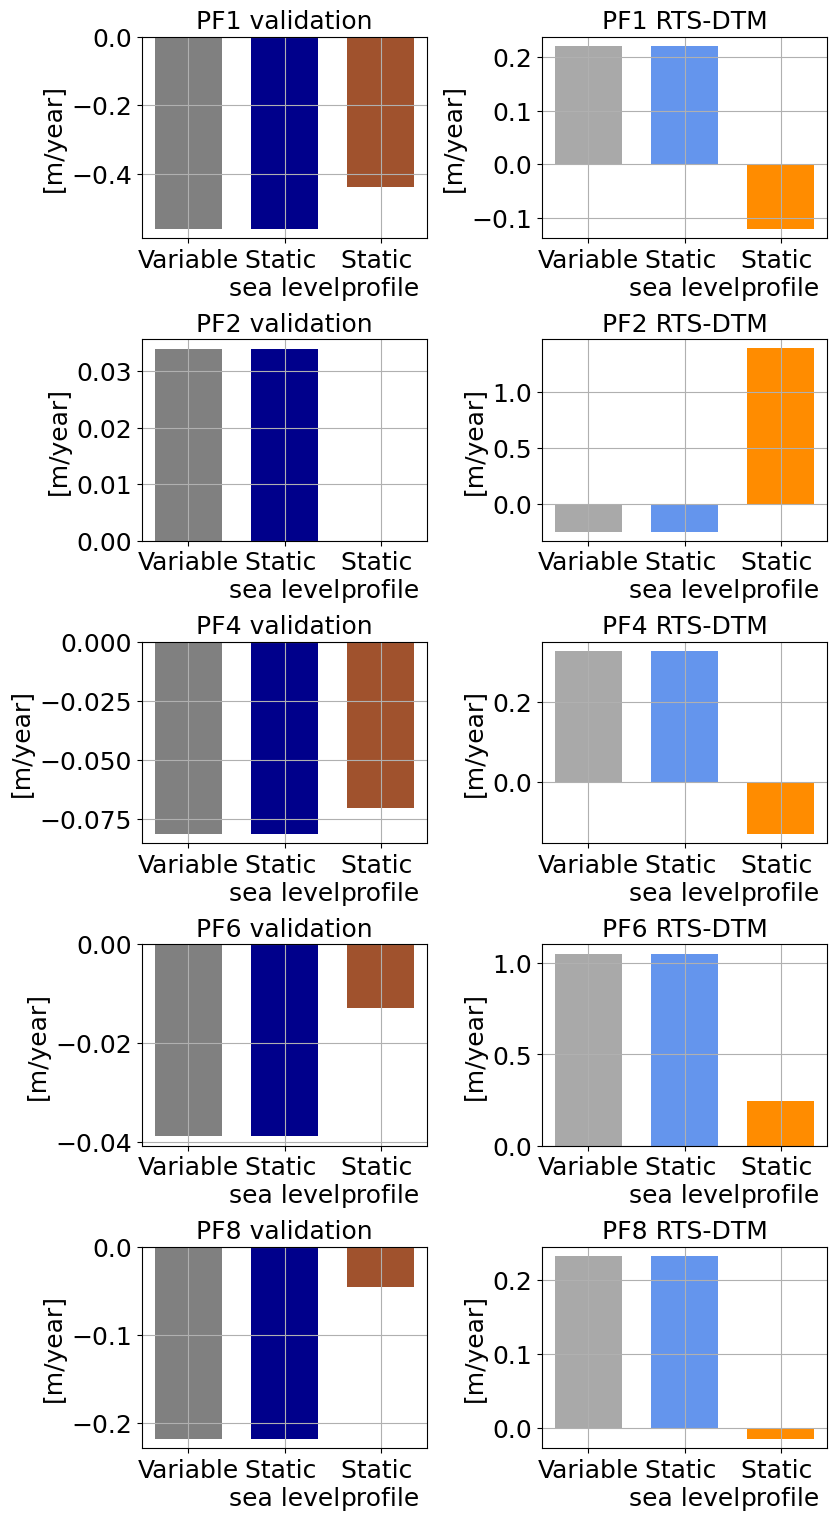

In [22]:
def plot_bars_vali(ax, profile):
    width=.7
    ax.bar(0, trend_vali_variable.loc[profile].trend, color='grey', width=width)
    ax.bar(1, trend_vali_static_sl.loc[profile].trend, color='darkblue', width=width)
    ax.bar(2, trend_vali_static_profile.loc[profile].trend, color='sienna', width=width)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Variable', 'Static \nsea level', 'Static \nprofile'])
    ax.set_title(f'{profile} validation')
    ax.set_ylabel('[m/year]')
    ax.grid()
    
def plot_bars_rts(ax, profile):
    width=.7
    ax.bar(0, trend_rts_variable.loc[profile].trend, color='darkgrey', width=width)
    ax.bar(1, trend_rts_static_sl.loc[profile].trend, color='cornflowerblue', width=width)
    ax.bar(2, trend_rts_static_profile.loc[profile].trend, color='darkorange', width=width)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Variable', 'Static \nsea level', 'Static \nprofile'])
    ax.set_title(f'{profile} RTS-DTM')
    ax.set_ylabel('[m/year]')
    ax.grid()

fig, axs = plt.subplots(5,2, figsize=(8,15))
fig.tight_layout()
fig.subplots_adjust(wspace=.4)
fig.subplots_adjust(hspace=.5)
plot_bars_vali(axs[0,0], profile='PF1')
plot_bars_rts(axs[0,1], profile='PF1')
plot_bars_vali(axs[1,0], profile='PF2')
plot_bars_rts(axs[1,1], profile='PF2')
plot_bars_vali(axs[2,0], profile='PF4')
plot_bars_rts(axs[2,1], profile='PF4')
plot_bars_vali(axs[3,0], profile='PF6')
plot_bars_rts(axs[3,1], profile='PF6')
plot_bars_vali(axs[4,0], profile='PF8')
plot_bars_rts(axs[4,1], profile='PF8')

In [23]:
def print_results(trend_df):
    for profile in trend_df.index:
        print(f'{profile}: {round(trend_df.loc[profile].trend, 2)} m/year')

In [24]:
print(f'Average trends, validation data set:')
print(f'\n1) Variable profile and variable sea level:')
print_results(trend_vali_variable)

print(f'\n2) Variable profile and static sea level:')
print_results(trend_vali_static_sl)

print(f'\n3) Static profile and variable sea level:')
print_results(trend_vali_static_profile)

print(f'\n\nAverage trends, RTS-DTM:\n')
print(f'1) Variable profile and variable sea level:')
print_results(trend_rts_variable)

print(f'\n2) Variable profile and static sea level:')
print_results(trend_rts_static_sl)

print(f'\n3) Static profile and variable sea level:')
print_results(trend_rts_static_profile)

Average trends, validation data set:

1) Variable profile and variable sea level:
PF1: -0.56 m/year
PF2: 0.03 m/year
PF4: -0.08 m/year
PF6: -0.04 m/year
PF8: -0.22 m/year

2) Variable profile and static sea level:
PF1: -0.56 m/year
PF2: 0.03 m/year
PF4: -0.08 m/year
PF6: -0.04 m/year
PF8: -0.22 m/year

3) Static profile and variable sea level:
PF1: -0.44 m/year
PF2: -0.0 m/year
PF4: -0.07 m/year
PF6: -0.01 m/year
PF8: -0.05 m/year


Average trends, RTS-DTM:

1) Variable profile and variable sea level:
PF1: 0.22 m/year
PF2: -0.25 m/year
PF4: 0.33 m/year
PF6: 1.05 m/year
PF8: 0.23 m/year

2) Variable profile and static sea level:
PF1: 0.22 m/year
PF2: -0.25 m/year
PF4: 0.33 m/year
PF6: 1.05 m/year
PF8: 0.23 m/year

3) Static profile and variable sea level:
PF1: -0.12 m/year
PF2: 1.39 m/year
PF4: -0.13 m/year
PF6: 0.24 m/year
PF8: -0.02 m/year
